In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Dataset Loading and Exploratory data analysis

In [2]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/customer_behavior/customer_dataset/customer_shopping_behavior.csv')
df.head()


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [103]:
df. info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [17]:
#description of the dataset
df.describe(include='all')

,customer_id,age,gender,item_purchased,category,purchase_amount,location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,promo_code_used,previous_purchases,payment_method,frequency_of_purchases,age_group
count,3900.000000,3900.000000,3900,3900,3900,3900.000000,3900,3900,3900,3900,3863.000000,3900,3900,3900,3900,3900.000000,3900,3900,3900
unique,NaN,NaN,2,25,4,NaN,50,4,25,4,NaN,2,6,2,2,NaN,6,7,4
top,NaN,NaN,Male,Blouse,Clothing,NaN,Montana,M,Olive,Spring,NaN,No,Free Shipping,No,No,NaN,PayPal,Every 3 Months,Young Adult
freq,NaN,NaN,2652,171,1737,NaN,96,1755,177,999,NaN,2847,675,2223,2223,NaN,677,584,1028
mean,1950.500000,44.068462,NaN,NaN,NaN,59.764359,NaN,NaN,NaN,NaN,3.750065,NaN,NaN,NaN,NaN,25.351538,NaN,NaN,NaN
std,1125.977353,15.207589,NaN,NaN,NaN,23.685392,NaN,NaN,NaN,NaN,0.716983,NaN,NaN,NaN,NaN,14.447125,NaN,NaN,NaN
min,1.000000,18.000000,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN
25%,975.750000,31.000000,NaN,NaN,NaN,39.000000,NaN,NaN,NaN,NaN,3.100000,NaN,NaN,NaN,NaN,13.000000,NaN,NaN,NaN
50%,1950.500000,44.000000,NaN,NaN,NaN,60.000000,NaN,NaN,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,25.000000,NaN,NaN,NaN
75%,2925.250000,57.000000,NaN,NaN,NaN,81.000000,NaN,NaN,NaN,NaN,4.400000,NaN,NaN,NaN,NaN,38.000000,NaN,NaN,NaN


In [15]:
#missing values checking
df.isnull().sum()

,0
customer_id,0
age,0
gender,0
item_purchased,0
category,0
purchase_amount,0
location,0
size,0
color,0
season,0


In [20]:
#Missing values Handling
df['review_rating']= df.groupby('category')['review_rating'].transform(lambda x: x.fillna(x.median()))

In [13]:
#missing values checking
df.isnull().sum()
df.head()

,customer_id,age,gender,item_purchased,category,purchase_amount,location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,promo_code_used,previous_purchases,payment_method,frequency_of_purchases,age_group
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly,Middle-aged
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly,Young Adult
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly,Middle-aged
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly,Young Adult
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually,Middle-aged


In [8]:
#column names uniformity
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ', '_')
df= df.rename(columns={'purchase_amount_(usd)': 'purchase_amount'})

In [9]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='object')

In [11]:
#feature engineering
# Creating an age_group column

labels = ['Young Adult', 'Adult', 'Middle-aged', 'Senior']
df['age_group'] = pd.qcut(df['age'], q=4, labels = labels)

In [12]:
df[['age', 'age_group']].head(10)

,age,age_group
0,55,Middle-aged
1,19,Young Adult
2,50,Middle-aged
3,21,Young Adult
4,45,Middle-aged
5,46,Middle-aged
6,63,Senior
7,27,Young Adult
8,26,Young Adult
9,57,Middle-aged


In [110]:
#Creating a column for the frequency_days of purchase
frequency_mapping = {
    'Fortnightly': 14,
    'Weekly': 7,
    'Monthly': 30,
    'Quarterly': 90,
    'Bi-Weekly':14,
    'Annually': 365,
    'Every 3 Months': 90
}

df['purchase_frequency_days'] = df['frequency_of_purchases'].map(frequency_mapping)

In [113]:
df[['purchase_frequency_days', 'frequency_of_purchases']].head(10)

,purchase_frequency_days,frequency_of_purchases
0,14,Fortnightly
1,14,Fortnightly
2,7,Weekly
3,7,Weekly
4,365,Annually
5,7,Weekly
6,90,Quarterly
7,7,Weekly
8,365,Annually
9,90,Quarterly


In [115]:
# confirming no missing values checking
df.isnull().sum()

,0
customer_id,0
age,0
gender,0
item_purchased,0
category,0
purchase_amount,0
location,0
size,0
color,0
season,0


In [117]:
df[['discount_applied', 'promo_code_used']]. head(10)

,discount_applied,promo_code_used
0,Yes,Yes
1,Yes,Yes
2,Yes,Yes
3,Yes,Yes
4,Yes,Yes
5,Yes,Yes
6,Yes,Yes
7,Yes,Yes
8,Yes,Yes
9,Yes,Yes


In [116]:
(df['discount_applied'] == df['promo_code_used']).all()


np.True_

In [43]:
df = df.drop('promo_code_used', axis=1, errors='ignore')

In [23]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases', 'age_group'],
      dtype='object')

In [24]:
df.head()

,customer_id,age,gender,item_purchased,category,purchase_amount,location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,promo_code_used,previous_purchases,payment_method,frequency_of_purchases,age_group
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly,Middle-aged
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly,Young Adult
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly,Middle-aged
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly,Young Adult
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually,Middle-aged


Data visualisation

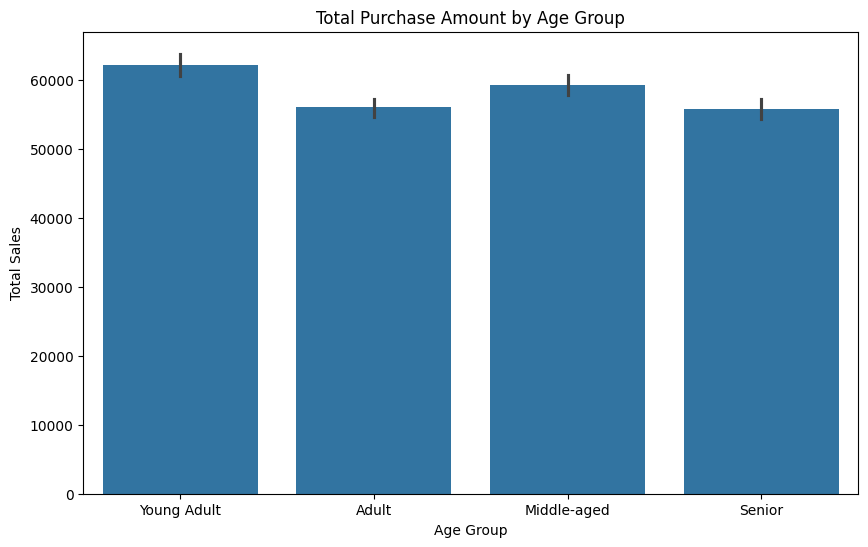

In [29]:
#Purchase amount per age group
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='age_group', y='purchase_amount', data=df, estimator=sum)
plt.title('Total Purchase Amount by Age Group')
plt.ylabel('Total Sales')
plt.xlabel('Age Group')
plt.show()

Database connexion

In [122]:
pip install SQLAlchemy

In [123]:
from sqlalchemy import create_engine

# SQLite database file will be created in the Colab environment
database_file = 'customer_behavior.db'

# Create a SQLAlchemy engine for SQLite
# 'sqlite:///' specifies a local file-based database
engine = create_engine(f'sqlite:///{database_file}')

# Load the DataFrame into the SQLite database
table_name = 'all_customer'
df.to_sql(table_name, engine, if_exists='replace', index=False)

print(f"DataFrame successfully loaded into table '{table_name}' in the SQLite database '{database_file}'.")

DataFrame successfully loaded into table 'all_customer' in the SQLite database 'customer_behavior.db'.


Running sql queries in database

In [124]:
query = "SELECT * FROM all_customer LIMIT 10"
result = pd.read_sql(query, engine)
print(result)

   customer_id  age gender item_purchased     category  purchase_amount  \
0            1   55   Male         Blouse     Clothing               53   
1            2   19   Male        Sweater     Clothing               64   
2            3   50   Male          Jeans     Clothing               73   
3            4   21   Male        Sandals     Footwear               90   
4            5   45   Male         Blouse     Clothing               49   
5            6   46   Male       Sneakers     Footwear               20   
6            7   63   Male          Shirt     Clothing               85   
7            8   27   Male         Shorts     Clothing               34   
8            9   26   Male           Coat    Outerwear               97   
9           10   57   Male        Handbag  Accessories               31   

        location size      color  season  review_rating subscription_status  \
0       Kentucky    L       Gray  Winter            3.1                 Yes   
1          Maine

Business insights on data

In [125]:
#Total revenue generated by male vs female customers

query = """
SELECT gender, SUM(purchase_amount) AS total_revenue
FROM all_customer
GROUP BY gender
"""
revenue_df = pd.read_sql(query, engine)
print(revenue_df)

   gender  total_revenue
0  Female          75191
1    Male         157890


In [126]:
#Customers who used a discount but still spent more than the average purchase amount
query = """
SELECT customer_id, purchase_amount
FROM all_customer
WHERE discount_applied = 'Yes' AND purchase_amount >= (SELECT AVG(purchase_amount) FROM all_customer)
"""
cust_df= pd.read_sql(query, engine)
print(cust_df)

     customer_id  purchase_amount
0              2               64
1              3               73
2              4               90
3              7               85
4              9               97
..           ...              ...
834         1667               64
835         1671               73
836         1673               73
837         1674               62
838         1676               90

[839 rows x 2 columns]


In [127]:
#Top 5 items with highest review rating
query = """
SELECT item_purchased, AVG(review_rating) AS avg_rating
FROM all_customer
GROUP BY item_purchased
ORDER BY avg_rating DESC
LIMIT 5
"""
top_items= pd.read_sql(query, engine)
top_items['avg_rating'] = top_items['avg_rating'].round(2)
print(top_items)

  item_purchased  avg_rating
0         Gloves        3.86
1        Sandals        3.84
2          Boots        3.82
3            Hat        3.80
4          Skirt        3.78


In [128]:
#Average purchase amount between standard and express shipping
query = """
SELECT shipping_type, AVG(purchase_amount) AS avg_purchase_amount
FROM all_customer
WHERE shipping_type IN ('Standard', 'Express')
GROUP BY shipping_type
"""
shipping_df = pd.read_sql(query, engine)
shipping_df['avg_purchase_amount'] = shipping_df['avg_purchase_amount'].round(2)
print(shipping_df)

  shipping_type  avg_purchase_amount
0       Express                60.48
1      Standard                58.46


In [129]:
#Compare average spend and total revenue btwn subscribed vs non
query = """
SELECT subscription_status, COUNT(customer_id) AS total_customers, AVG(purchase_amount) AS avg_spend, SUM(purchase_amount) AS total_revenue
FROM all_customer
GROUP BY subscription_status
ORDER BY total_revenue, avg_spend DESC
"""
spend_df = pd.read_sql(query, engine)
spend_df['avg_spend'] = spend_df['avg_spend'].round(2)
spend_df['total_revenue'] = spend_df['total_revenue'].round(2)
print(spend_df)

  subscription_status  total_customers  avg_spend  total_revenue
0                 Yes             1053      59.49          62645
1                  No             2847      59.87         170436


In [130]:
# Top 5 products with highest percentage of purchase with discount applied
query = """
SELECT item_purchased, (COUNT(CASE WHEN discount_applied = 'Yes' THEN 1 END) * 100.0 / COUNT(*)) AS discount_percentage
FROM all_customer
GROUP BY item_purchased
ORDER BY discount_percentage DESC
LIMIT 5
"""
discount_df = pd.read_sql(query, engine)
discount_df['discount_percentage'] = discount_df['discount_percentage'].round(2)
print(discount_df)
discount_df


  item_purchased  discount_percentage
0            Hat                50.00
1       Sneakers                49.66
2           Coat                49.07
3        Sweater                48.17
4          Pants                47.37


,item_purchased,discount_percentage
0,Hat,50.00
1,Sneakers,49.66
2,Coat,49.07
3,Sweater,48.17
4,Pants,47.37


In [131]:
#Total revenue by age group
query = """
SELECT age_group, SUM(purchase_amount) AS total_revenue
FROM all_customer
GROUP BY age_group
ORDER BY total_revenue ASC
"""
revenue_df = pd.read_sql(query, engine)
print(revenue_df)


     age_group  total_revenue
0       Senior          55763
1        Adult          55978
2  Middle-aged          59197
3  Young Adult          62143


In [132]:
# Download the SQLite database file
from google.colab import files

files.download('customer_behavior.db')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [133]:
query = "SELECT * FROM all_customer"
df_to_export = pd.read_sql(query, engine)
df_to_export.to_csv('all_customer_data.csv', index=False)

print("Data exported to 'all_customer_data.csv' successfully.")

Data exported to 'all_customer_data.csv' successfully.


In [134]:
from google.colab import files
files.download('all_customer_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>